In [14]:
# ===============================
# import packages
# ===============================
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
from datetime import datetime as dt, timezone, timedelta
from pathlib import Path
import plotly.express as px
import squarify
import seaborn as sns

In [2]:
import sys
print("Notebook is running on:")
print(sys.executable)

Notebook is running on:
c:\Users\Harry Turner\Documents\Personal Projects\01_2026\GridProject\venv\Scripts\python.exe


In [3]:
# ===============================
# system paths
# ===============================
script_dir = Path.cwd().parent
output_dir = script_dir / "data"

output_dir.mkdir(parents=True, exist_ok=True)

In [4]:
# ===============================
# 1 - Elexon generation data
# ===============================
# API request - generation data
url = 'https://data.elexon.co.uk/bmrs/api/v1/generation/outturn/summary'
today = dt.now(timezone.utc)
time_lag = timedelta(days=7)
start_date = pd.Timestamp(today - time_lag).round('D').strftime('%Y-%m-%d %H:%M:%S')
today = pd.Timestamp(today).strftime('%Y-%m-%d %H:%M:%S')

params = {
    'startTime' : start_date,
    'endTime' : today
}

response = requests.get(url, params = params)

if response.status_code == 200:
    print('Elexon generation API call successful!')
else:
    raise Exception(f"Elexon API failed. Status code: {response.status_code}")

gen = response.json()

gen = pd.json_normalize(
    gen,
    record_path=['data'],
    meta=['startTime', 'settlementPeriod']
)

# Convert data types - generation data
gen['settlementPeriod'] = pd.to_numeric(gen['settlementPeriod'])
gen['localTime'] = pd.to_datetime(gen['startTime'], utc=True).dt.tz_convert('Europe/London')
gen['startTime'] = gen['localTime'].dt.strftime('%Y-%m-%d')

gen = gen.pivot_table(
    index=['startTime', 'settlementPeriod'],
    columns='fuelType',
    values='generation'
).reset_index().rename_axis(None, axis=1)

Elexon generation API call successful!


In [5]:
# ===============================
# 2 - NESO demand data
# ===============================
# API request - NESO demand data
dmnd = pd.read_csv('https://api.neso.energy/dataset/7a12172a-939c-404c-b581-a6128b74f588/resource/177f6fa4-ae49-4182-81ea-0c6b35f26ca6/download/demanddataupdate.csv')

dmnd = pd.DataFrame(dmnd)

dmnd = dmnd.rename(
    columns={
        'SETTLEMENT_DATE': 'startTime',
        'SETTLEMENT_PERIOD': 'settlementPeriod'
    }
)

In [6]:
merged_data = pd.merge(dmnd, gen, on=['startTime', 'settlementPeriod'])


merged_data.columns

grid = merged_data[[
    'startTime',
    'settlementPeriod',
    'OIL',
    'CCGT',
    'OCGT',
    'COAL',
    'BIOMASS',
    'NUCLEAR',
    'WIND',
    'EMBEDDED_WIND_GENERATION',
    'EMBEDDED_SOLAR_GENERATION',
    'NPSHYD',
    'PS',
    'OTHER',
    'INTELEC',
    'INTFR',
    'INTIFA2',
    'INTNED',
    'INTIRL',
    'INTEW',
    'INTNEM',
    'INTNSL',
    'INTVKL'
]]


In [7]:
grid['startTime'] = pd.to_datetime(grid['startTime'])
grid['timestamp'] = grid['startTime'] + pd.to_timedelta((grid['settlementPeriod'] -1) * 30, unit='m')



grid = grid.drop('startTime', axis='columns')

grid = (
    grid
    .rename(columns={
        'OIL': 'oil',
        'CCGT': 'ccgt',
        'OCGT': 'ocgt',
        'COAL': 'coal',
        'BIOMASS': 'biomass',
        'NUCLEAR': 'nuclear',
        'WIND': 'wind',
        'EMBEDDED_WIND_GENERATION': 'wind_embedded',
        'EMBEDDED_SOLAR_GENERATION': 'solar',
        'PS': 'pumped_storage_hydro',
        'NPSHYD': 'non_pumped_storage_hydro',
        'OTHER': 'other'
    })
    .assign(
        gas = lambda x: x['ocgt'] + x['ccgt'],
        wind = lambda x: x['wind'] + x['wind_embedded']
    )
)

grid = grid.drop(columns=['ocgt', 'ccgt', 'wind_embedded'])

start_cols = ['timestamp', 'settlementPeriod', 'gas']
ordered_cols = start_cols + [c for c in grid.columns if c not in start_cols]
grid = grid[ordered_cols]
grid = grid.fillna(0)


print(grid.columns)



Index(['timestamp', 'settlementPeriod', 'gas', 'oil', 'coal', 'biomass',
       'nuclear', 'wind', 'solar', 'non_pumped_storage_hydro',
       'pumped_storage_hydro', 'other', 'INTELEC', 'INTFR', 'INTIFA2',
       'INTNED', 'INTIRL', 'INTEW', 'INTNEM', 'INTNSL', 'INTVKL'],
      dtype='str')


In [8]:
energy_categories = { 
    'gas': 'Fossil', 
    'oil': 'Fossil', 
    'coal': 'Fossil', 
    'biomass': 'Other',
    'nuclear': 'Other', 
    'wind': 'Renewable',
    'solar': 'Renewable', 
    'non_pumped_storage_hydro': 'Other',
    'pumped_storage_hydro': 'Other', 
    'other': 'Other', 
    'INTELEC': 'Interconnector', 
    'INTFR': 'Interconnector', 
    'INTIFA2': 'Interconnector',
    'INTNED': 'Interconnector', 
    'INTIRL': 'Interconnector', 
    'INTEW': 'Interconnector', 
    'INTGRNL': 'Interconnector', 
    'INTNEM': 'Interconnector', 
    'INTNSL': 'Interconnector', 
    'INTVKL': 'Interconnector'
}

grid_long = grid.melt(id_vars=['timestamp', 'settlementPeriod'],
                      var_name='source',
                      value_name='mw')

grid_long['category'] = grid_long['source'].map(energy_categories)

category_df = grid_long.groupby(['timestamp', 'category'])['mw'].sum().unstack(level='category')

In [21]:
print(grid_long.head(20))

heatmap_data = grid_long.groupby(['category', 'source'], as_index=False)['mw'].sum()

fig = px.treemap(
    heatmap_data,
    path = ['category', 'source'],
    values='mw',
    color_continuous_scale='Blues'
)

fig.show()

             timestamp  settlementPeriod source      mw category
0  2026-07-18 01:00:00                 3    gas  7529.0   Fossil
1  2026-07-18 01:30:00                 4    gas  6667.0   Fossil
2  2026-07-18 02:00:00                 5    gas  5967.0   Fossil
3  2026-07-18 02:30:00                 6    gas  5387.0   Fossil
4  2026-07-18 03:00:00                 7    gas  5111.0   Fossil
5  2026-07-18 03:30:00                 8    gas  4529.0   Fossil
6  2026-07-18 04:00:00                 9    gas  3906.0   Fossil
7  2026-07-18 04:30:00                10    gas  3105.0   Fossil
8  2026-07-18 05:00:00                11    gas  2909.0   Fossil
9  2026-07-18 05:30:00                12    gas  2911.0   Fossil
10 2026-07-18 06:00:00                13    gas  3099.0   Fossil
11 2026-07-18 06:30:00                14    gas  2939.0   Fossil
12 2026-07-18 07:00:00                15    gas  2999.0   Fossil
13 2026-07-18 07:30:00                16    gas  2866.0   Fossil
14 2026-07-18 08:00:00   

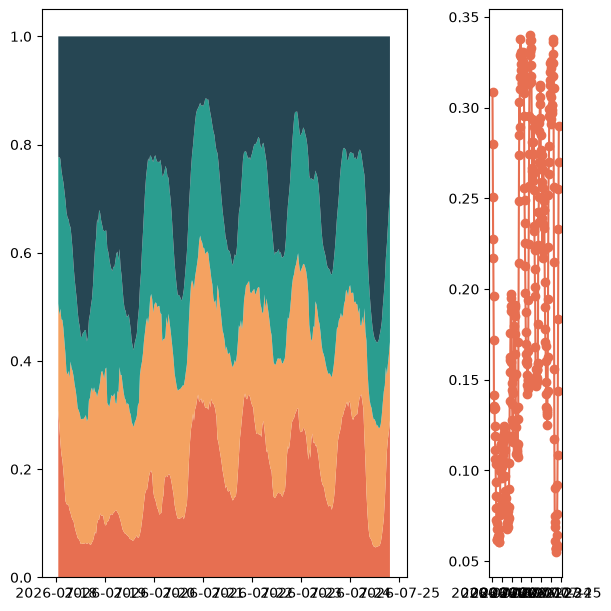

In [10]:
# plot 1 - stacked area 30 min generation
cat_data = grid_long.groupby(['timestamp', 'category'])['mw'].sum().reset_index()
cat_wide = cat_data.pivot(index='timestamp', columns='category', values='mw').fillna(0)
cat_perc = cat_wide.div(cat_wide.sum(axis=1), axis=0)

# plot 2 - stacked bar weekly summary




fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6,6), gridspec_kw={'width_ratios': [5, 1]},
                               layout='constrained')

plt.rcParams.update({'font.size': 9})
title_font = {'fontname':'Karla',
              'fontsize': 20}

colour = ['#e76f51', '#f4a261', '#2a9d8f', '#264653']

ax1.stackplot(cat_perc.index,
              cat_perc.T,
              labels=cat_perc.columns,
              colors=colour)

ax2.plot(cat_perc.index, cat_perc.iloc[:, 0], color=colour[0], marker='o')

plt.show()


In [11]:
print(cat_data.head(10))

            timestamp        category      mw
0 2026-07-18 01:00:00          Fossil  7529.0
1 2026-07-18 01:00:00  Interconnector  4824.0
2 2026-07-18 01:00:00           Other  6618.0
3 2026-07-18 01:00:00       Renewable  5438.0
4 2026-07-18 01:30:00          Fossil  6667.0
5 2026-07-18 01:30:00  Interconnector  4878.0
6 2026-07-18 01:30:00           Other  6936.0
7 2026-07-18 01:30:00       Renewable  5313.0
8 2026-07-18 02:00:00          Fossil  5967.0
9 2026-07-18 02:00:00  Interconnector  5840.0
